# Seaborn — Statistical Charts on Top of Matplotlib

> 📘 **Instructor Curriculum** — M02, Data Visualization with Python

**What this notebook is:** a hands-on tour of `seaborn`, covering relational plots
(`lineplot`, `scatterplot`), distribution plots (`histplot`, `kdeplot`), categorical
plots (`barplot`, `boxplot`, `violinplot`, `countplot`, `stripplot`, `swarmplot`),
regression (`regplot`), grids (`pairplot`, `FacetGrid`), and global styling
(`set_theme`, `set_palette`).

**How to read it:** like the Matplotlib notebook, this is a **ladder**. Most cells repeat
the cell above and change exactly one argument. The useful question at each step is
*what is different from the cell before?* Each Markdown section explains every code cell
that follows it, up to the next section.

Versions used here: **seaborn 0.13.2**, **matplotlib 3.10.9**.

---

## The mental model — read this first

Seaborn does **not** replace matplotlib. It sits on top of it and writes matplotlib code
for you:

```text
   your call            seaborn's job                    matplotlib's job
   ---------            -------------                    ----------------
   sns.barplot(         1. group the rows                draw rectangles
     x="day",           2. run statistics (mean)         draw error bars
     y="total_bill",    3. pick colors from a palette    draw ticks, labels
     data=tips)        4. build the legend               return an Axes
                              |
                              v
                        matplotlib Axes  <-- you can still style this by hand
```

That layering explains three things you will see all over this notebook:

1. Every plot returns a matplotlib `Axes`, so `plt.show()`, `plt.title()` and friends
   still work.
2. Seaborn arguments are about **data** (`x="day"`, `hue="sex"`), not about pixels.
3. When seaborn cannot do something, you drop down to matplotlib — that is normal, not
   a workaround.

### The one contract seaborn expects: long-form data

```text
WIDE form (what a spreadsheet looks like)     LONG form (what seaborn wants)
+--------+--------+                           +---------+--------------+
| setosa | virgin |                           | species | sepal_length |
+--------+--------+                           +---------+--------------+
|  5.1   |  6.3   |                           | setosa  |     5.1      |
|  4.9   |  5.8   |                           | setosa  |     4.9      |
+--------+--------+                           | virgin  |     6.3      |
                                              | virgin  |     5.8      |
                                              +---------+--------------+
                                                   ^            ^
                                              a grouping    a measurement
                                               column         column
```

In long form, **every column is a variable and every row is one observation**. That is
why almost every call in this notebook looks the same shape:

```text
sns.<plot>(x=<column>, y=<column>, hue=<column>, data=<DataFrame>)
```

You are naming columns, not passing numbers.

> 💡 **Engineering Extension** — *Recommended Extension - Not part of instructor curriculum.*
>
> Long form is the same idea as a **normalized table** versus a pivoted report. Seaborn
> is the reporting layer: give it normalized rows and tell it which column plays which
> role, and it does the `GROUP BY` and the aggregation itself. `hue="species"` is
> literally a `GROUP BY species` whose output channel happens to be colour instead of a
> result set.

### Figure-level vs axes-level — the split that confuses everyone

| Kind | Examples in this notebook | Draws into | Returns |
|---|---|---|---|
| **Axes-level** | `lineplot`, `scatterplot`, `histplot`, `kdeplot`, `barplot`, `boxplot`, `violinplot`, `countplot`, `stripplot`, `swarmplot`, `regplot` | one existing Axes | `Axes` |
| **Figure-level** | `pairplot`, `FacetGrid` | creates its **own** whole Figure | `PairGrid` / `FacetGrid` |

Practical consequence: a figure-level call **ignores** a figure you made earlier and
cannot be placed inside a subplot. That is why `pairplot` in this notebook always lands
on its own canvas.

---

## 1. Setup — the import cells

| Cell | Why it exists |
|---|---|
| `import seaborn as sns` | The whole plotting API lives at the top level — unlike matplotlib, there is no second submodule import. The alias `sns` is universal convention. |
| `import numpy as np` | The first two plots feed seaborn raw NumPy arrays. |
| `import pandas as pd` | Seaborn is built around the pandas `DataFrame`. Every dataset below is one. |
| `print(sns.__version__)` | Prints `0.13.2`. Checking this first is not ceremony — **0.13 changed real behaviour**, most notably that `palette=` now requires `hue=`. Snippets written for 0.11 or 0.12 will warn or fail here. |

**Takeaway:** `import seaborn as sns` is the entire import. But seaborn without pandas is
half a tool — the DataFrame is the interface.

In [25]:
import seaborn as sns
import numpy as np
import pandas as pd

In [3]:
print(sns.__version__)

0.13.2


---

## 2. Your first plots — arrays vs DataFrame

The next three cells build the same straight line twice, through two different doors.

```python
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2,4,6,8,10,12,14,16,18,20])
```

`y` is exactly `2 * x`. Deliberately boring data: when the numbers are predictable, every
visual change you see comes from the **argument**, not the data. Same experiment design
as the Matplotlib notebook.

| Cell | Call | What it teaches |
|---|---|---|
| Setup | the two `np.array` lines | Plain arrays, no DataFrame yet. |
| A | `sns.lineplot(x=x, y=y)` | Seaborn accepts **raw arrays** positionally by keyword. No `data=` needed. |
| B | `sns.lineplot(x='x', y='y', data=df)` | The normal seaborn style: `x` and `y` are now **strings naming columns**, and `data=` supplies the frame. |

Look at the two charts — they are identical. So why prefer B?

```text
A:  x=<array>   ->  seaborn gets numbers.  Axis label: none (it has no name)
B:  x='x'       ->  seaborn gets a NAME.   Axis label: "x"  (taken from the column)
```

That is the real difference and it scales: with `data=`, seaborn can auto-label axes,
build legends, and group by other columns, because it knows what the numbers are
*called*. With bare arrays it only has numbers.

**Common mistake:** writing `sns.lineplot(x, y)` positionally. In seaborn 0.13 the first
positional parameter is `data`, so this raises an error. Always use keywords.

**Takeaway:** raw arrays work for a throwaway plot. Pass `data=` plus column names for
everything else — the extra features all depend on seaborn knowing the column names.

In [4]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2,4,6,8,10,12,14,16,18,20])

<Axes: >

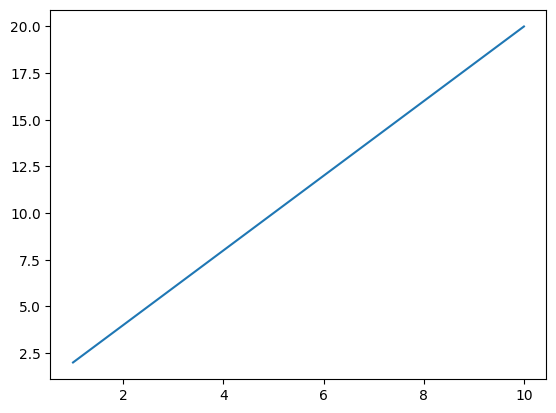

In [7]:
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2,4,6,8,10,12,14,16,18,20])
sns.lineplot(x=x,y=y)


<Axes: xlabel='x', ylabel='y'>

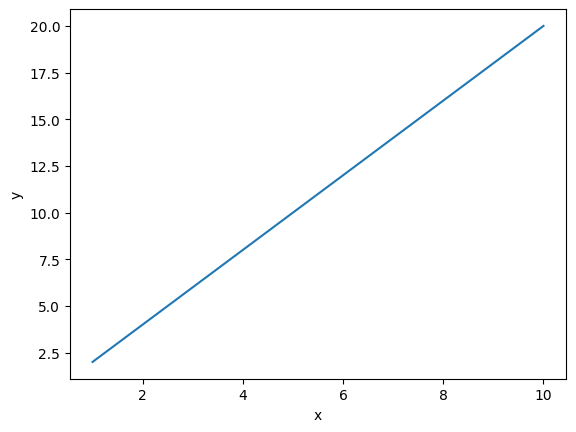

In [10]:
df = pd.DataFrame({
 'x': x,
 'y': y
})
sns.lineplot(x='x', y='y', data=df)

---

## 3. Built-in datasets — `sns.load_dataset`

`sns.load_dataset("iris")` downloads a small, well-known CSV from the seaborn-data
repository and returns it as a DataFrame. Three datasets are used in this notebook:

| Dataset | Shape (verified) | Used for |
|---|---|---|
| `iris` | 150 rows × 5 cols (4 numeric + `species`) | relational and distribution plots |
| `titanic` | 891 rows × 15 cols | `barplot` |
| `tips` | 244 rows × 7 cols | categorical plots, facets, regression |

The `iris` frame is perfectly balanced — **50 rows per species** (`setosa`, `versicolor`,
`virginica`). That matters later: `countplot` on `species` will show three bars of
exactly equal height, which is a check that the plot is doing what you think.

`print(data)` truncates the middle rows and shows `[150 rows x 5 columns]` at the bottom.
That row/column count is the fastest sanity check you have before plotting anything.

> ⚠️ These datasets need **network access** on first use. They are convenience data for
> learning. Real work reads local files with a relative path.

**Takeaway:** `load_dataset` gives you a clean long-form DataFrame instantly, so you can
practise the plotting API without spending the lesson on data cleaning.

In [ ]:
data = sns.load_dataset("iris")
print(data)

     sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]


---

## 4. Relational plots and the three semantic channels

This is the core idea of seaborn. You **map a column onto a visual property**:

```text
       DATA COLUMN                VISUAL CHANNEL
       -----------                --------------
       species        --hue-->    colour
       species        --size-->   marker size
       species        --style-->  marker shape / line dash
```

Seaborn calls these **semantics**. Each one splits the data into groups, draws each group
separately, and builds a legend automatically.

### The four cells

| Cell | Call | The one new thing |
|---|---|---|
| A | `sns.scatterplot(x="sepal_length", y="petal_length", data=data)` | Baseline. One colour, 150 dots, no grouping. Two clusters are already visible. |
| B | `sns.lineplot(..., hue="species")` | `hue` splits into 3 groups → 3 coloured lines + legend. |
| C | `sns.lineplot(..., hue="species", style="species", markers=True)` | `style` adds a **second** channel on the same column: each group now differs by colour *and* dash/marker. |
| D | `sns.scatterplot(..., hue="species", size="species", sizes=(20,100))` | `size` maps the column to marker area; `sizes=(20,100)` sets the smallest and largest area in points². |

### Why the lineplots look strange — and what they prove

`lineplot` is designed for data with a **natural order**, usually time. Here `x` is
`sepal_length`, which is a measurement with many repeated values. So seaborn does two
things you did not ask for, and both are visible in the output:

```text
50 setosa rows
      |
      +-- sort by sepal_length
      +-- GROUP rows that share the same x
      +-- estimator="mean"  -> one y per unique x        -> the line
      +-- errorbar=("ci",95) -> bootstrap 1000 resamples -> the shaded band
```

Verified on this data: the 50 `setosa` rows collapse to **15 plotted points**, because
`sepal_length` only has 15 distinct values within that species (35 distinct values across
all 150 rows). The shaded band around each line is a **95% confidence interval**, not a
data range.

So the jagged lines and shaded bands are not noise — they are seaborn silently doing
statistics. This is the single biggest difference from matplotlib, where `plt.plot` draws
exactly the points you hand it and nothing else.

**Correct tool for this data:** `scatterplot` (cell A) — which is why the scatter version
reads so much more clearly.

### `size=` on a categorical column

`size="species"` works, but species is a **category**, not a quantity. A bigger dot
implies "more", and there is no "more" here — `virginica` is not larger than `setosa` in
any meaningful sense. It is a good demonstration of the channel and a poor chart. Use
`size` for genuine quantities (population, revenue, count).

`data.info()` in that cell prints the dtypes: 4 `float64` columns and 1 `object`
(`species`). Checking dtypes before plotting is a real habit — seaborn treats numeric and
categorical columns differently.

### Common mistakes

1. `hue="orange"` — `hue` takes a **column name**, never a colour. Use `color=` for a colour.
2. Using `lineplot` on unordered data, as above. Ask "does connecting point 1 to point 2 mean anything?" If no, use `scatterplot`.
3. Expecting `lineplot` to draw every row. It aggregates by default.
4. Mapping `size` to a category, as in cell D.

**Takeaway:** `hue`, `size` and `style` are `GROUP BY` for charts. Pick the channel that
matches the data type — colour for categories, size for quantities.

<Axes: xlabel='sepal_length', ylabel='petal_length'>

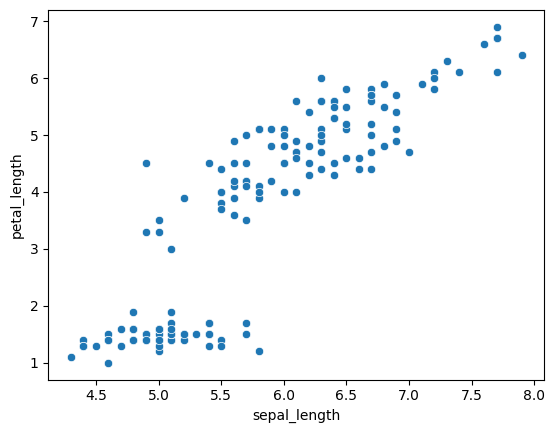

In [12]:
sns.scatterplot(x="sepal_length",y = "petal_length",data= data)

<Axes: xlabel='sepal_length', ylabel='petal_length'>

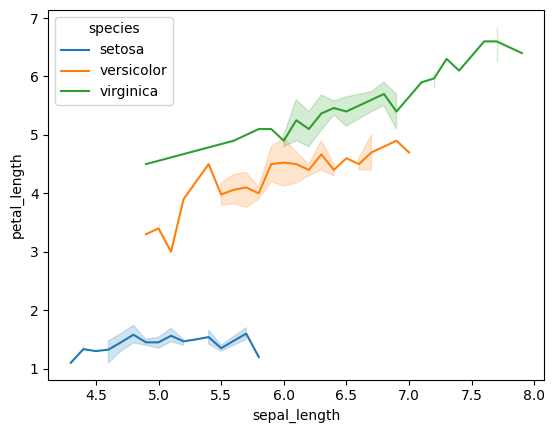

In [13]:
data = sns.load_dataset('iris')
sns.lineplot(x = "sepal_length", y = "petal_length", data = data, hue="species")

<Axes: xlabel='sepal_length', ylabel='petal_length'>

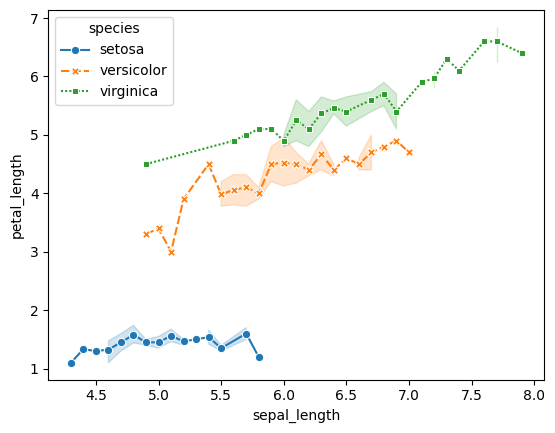

In [17]:
data = sns.load_dataset('iris')
sns.lineplot(x="sepal_length", y="petal_length", data=data,hue="species",style="species", markers=True)

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


<Axes: xlabel='sepal_length', ylabel='petal_length'>

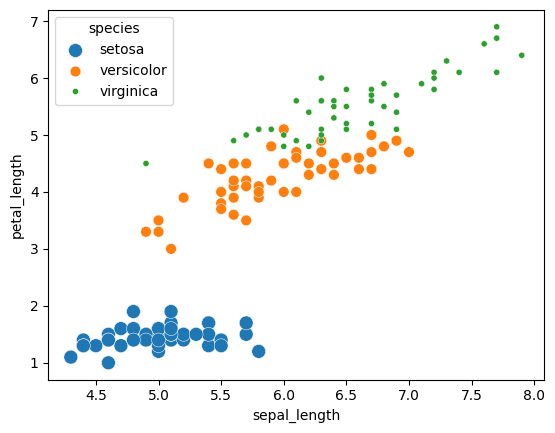

In [24]:
data = sns.load_dataset("iris")
data.info()
sns.scatterplot(x="sepal_length",y = "petal_length", hue="species", size="species",data=data,sizes=(20, 100))

---

## 5. Distributions — `histplot` and `kdeplot`

The plots above compare **two** variables. These four cells describe **one** variable:
where are the values concentrated?

```text
raw values                histplot                    kdeplot
-----------               --------                    -------
5.1 4.9 4.7 ...    ->     chop the range into bins    ->  smooth curve
                          count rows per bin              (estimated density)
                          draw a rectangle
```

| Cell | Call | The one new thing |
|---|---|---|
| A | `sns.histplot(x="sepal_length", data=data)` | Baseline histogram. Bin count is chosen automatically — **9 bars** for this column. |
| B | `sns.histplot(..., kde=True, color="purple")` | `kde=True` overlays the smooth curve on the bars. `color=` sets **one** colour for the whole plot. |
| C | `sns.kdeplot(data=data, x="sepal_length")` | The curve on its own, no bars. |
| D | `sns.kdeplot(..., hue="species", fill=True, alpha=0.4)` | `hue` gives **one curve per species**; `fill=True` shades under each; `alpha=0.4` makes the overlaps readable. |

### Why cell D is the payoff

Cells A–C show a single lumpy hill and hide the truth. Cell D splits it and the structure
appears: `setosa` sits clearly to the left, `versicolor` and `virginica` overlap heavily.
That is the same grouping insight the scatterplot gave, seen from the distribution side.

`alpha=0.4` is doing real work. Without transparency the third curve hides the first two.

### Histogram vs KDE — the honest trade-off

| | `histplot` | `kdeplot` |
|---|---|---|
| Shows | actual counts | estimated density |
| Y axis | rows per bin | density (area sums to 1) |
| Risk | bin width changes the story | smoothing can invent a shape that is not in the data |
| Best for | reporting real counts | comparing several groups |

Neither is "better". `kde=True` in cell B gives you both at once, which is usually the
right answer for exploration.

### Common mistakes

1. Trusting a KDE on very few rows — smoothing will produce a confident-looking curve from almost nothing.
2. Reading the KDE y-axis as a count. It is a density.
3. Overlaying groups without `alpha`, so later groups hide earlier ones.

**Takeaway:** a single distribution usually hides the interesting part. Add
`hue=<group column>` and the structure appears.

<Axes: xlabel='sepal_length', ylabel='Count'>

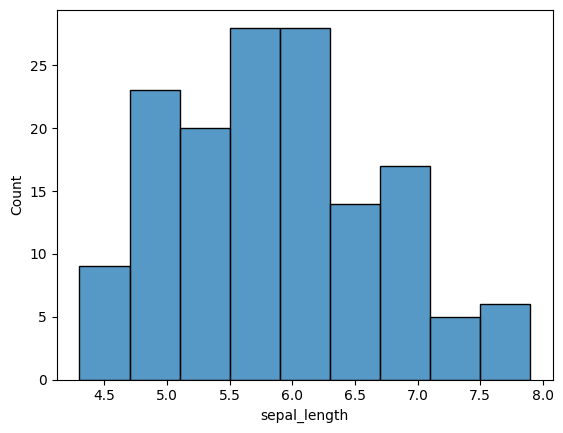

In [29]:
sns.histplot(x="sepal_length", data=data)

<Axes: xlabel='sepal_length', ylabel='Count'>

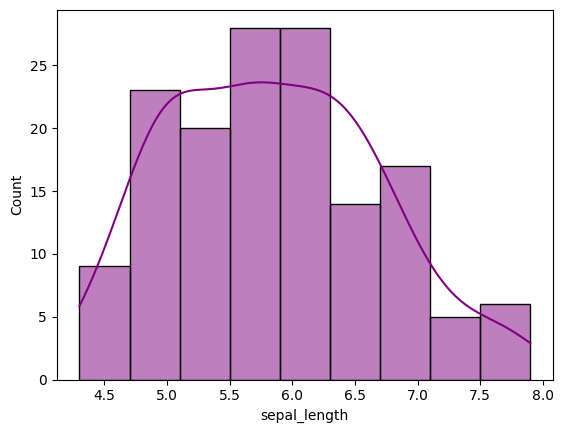

In [32]:
sns.histplot(data=data, x="sepal_length", kde=True, color="purple")

<Axes: xlabel='sepal_length', ylabel='Density'>

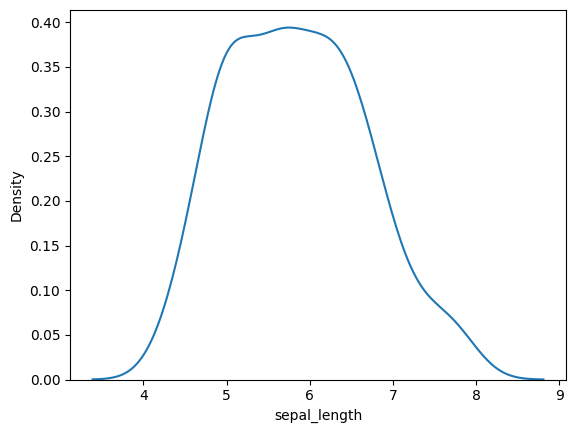

In [34]:
sns.kdeplot(data=data, x="sepal_length")

<Axes: xlabel='sepal_length', ylabel='Density'>

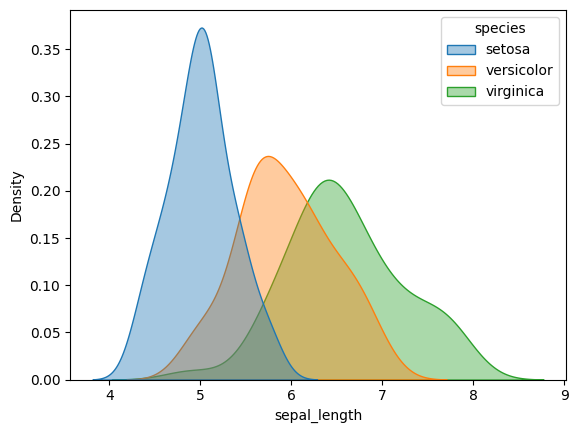

In [38]:
sns.kdeplot(data= data, x = "sepal_length", hue= "species", fill = True, alpha=0.4)

---

## 6. `pairplot` — every numeric pair at once

```python
sns.pairplot(data, hue="species", markers=["o", "s", "D"])
```

One line, and seaborn draws a **4 × 4 grid** — verified — because `iris` has 4 numeric
columns. It is the highest information-per-keystroke call in the whole library.

```text
              sepal_l   sepal_w   petal_l   petal_w
            +---------+---------+---------+---------+
  sepal_l   |  DIST   | scatter | scatter | scatter |   diagonal = distribution
            +---------+---------+---------+---------+   of that one column
  sepal_w   | scatter |  DIST   | scatter | scatter |
            +---------+---------+---------+---------+   off-diagonal = scatter
  petal_l   | scatter | scatter |  DIST   | scatter |   of the pair
            +---------+---------+---------+---------+
  petal_w   | scatter | scatter | scatter |  DIST   |   mirror across the diagonal
            +---------+---------+---------+---------+
```

| Argument | Effect |
|---|---|
| `data` | passed **positionally** here — the first parameter of `pairplot` really is the DataFrame |
| `hue="species"` | colours every panel by species and adds one shared legend |
| `markers=["o","s","D"]` | one marker per hue level: circle, square, diamond. **The list length must equal the number of hue levels** — 3 species, 3 markers |

The markers argument is an accessibility habit worth keeping: the groups stay
distinguishable when the chart is printed in greyscale or read by someone with colour
blindness. Colour alone is a single point of failure.

### What to read off it

Look along the `petal_length` and `petal_width` rows: `setosa` separates completely from
the other two. Those two columns alone would classify it. That is genuine feature
selection done by eye, in one line of code — and it is why `pairplot` is usually the
first thing to run on a new numeric dataset.

⚠️ **Cost:** it draws n² panels. Four columns is fine. Twenty columns is 400 panels and a
long wait. Slice the frame first: `sns.pairplot(df[["a","b","c","target"]], hue="target")`.

> 💡 **Engineering Extension** — *Recommended Extension - Not part of instructor curriculum.*
>
> `pairplot` is **figure-level**: it builds its own Figure and returns a `PairGrid`, so it
> cannot be dropped into an existing subplot. Think of it as a component that renders its
> own container rather than one you mount into a layout.

**Takeaway:** run `pairplot` first on a new numeric dataset. Correlations and separable
classes appear immediately, before you write any model code.

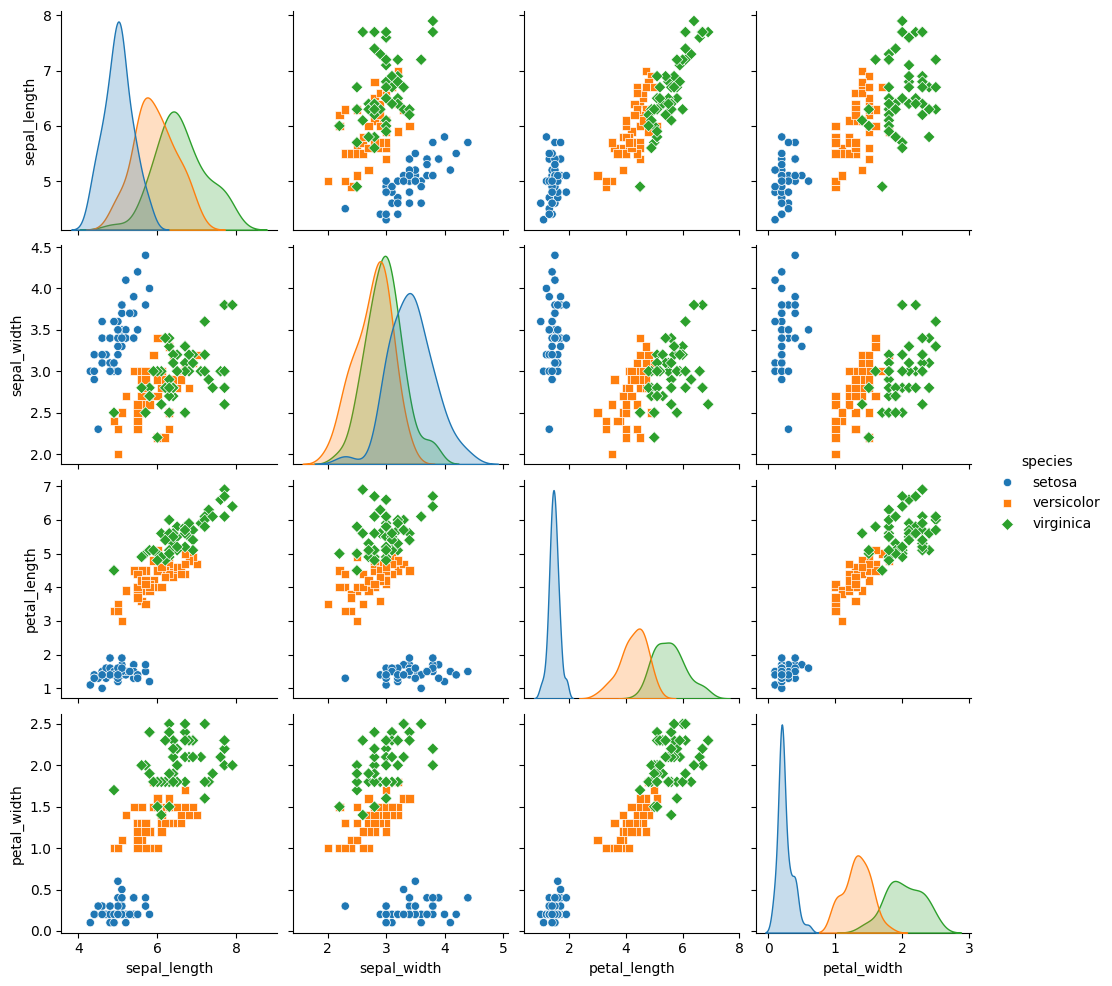

In [44]:
sns.pairplot(data, hue="species", markers=["o", "s", "D"])

---

## 7. `violinplot` — distribution per category

```python
sns.violinplot(x="species", y="sepal_length", data=data,
               hue="species", palette=["orange", "skyblue", "lightgreen"],
               legend=False)
```

A violin is **a KDE curve mirrored around its own axis**, drawn once per category. It
answers "what does the distribution look like *inside* each group?"

```text
  a kdeplot rotated,          one violin per category
  mirrored, and repeated:
                                setosa   versicolor  virginica
       (|)                        (|)       ( | )      (  |  )
        |     <- wide = many      /|\       /  \       /     \
       (|)       rows near        \|/       \  /       \     /
                 this value        (|)       (|)         (|)
```

### The colour arguments — and the 0.13 rule behind them

| Argument | Role |
|---|---|
| `hue="species"` | **what to split by** — the mapping |
| `palette=[...]` | **which colours** to use for those groups |
| `legend=False` | hides the legend, which repeats the x-axis labels here |

This is the rule that trips up every 0.13 upgrade:

```text
color="orange"        ->  ONE colour for the whole plot
palette=[...]         ->  IGNORED unless something is mapped to it
hue="species" + palette -> three colours, one per species   <-- correct
```

`palette` without `hue` is deprecated in 0.13 and warns. Because `hue` repeats the `x`
column here, the legend adds nothing, hence `legend=False`.

**Palette alternatives:**

```python
palette="Set2"    # named palette, sizes itself to the category count
palette={"setosa": "orange", "versicolor": "skyblue", "virginica": "lightgreen"}
```

The dict form is safest for reports — a colour stays bound to its category even if the
plot order changes. A **list** palette must match the category count exactly or seaborn
raises an error.

### Violin vs box — what each one hides

A box plot cannot show a **two-humped** distribution; it draws the same box either way. A
violin shows the two humps. That is the whole reason to prefer it. The cost is that the
curve is smoothed, so it implies more precision than small data supports.

**Takeaway:** violin = box plot plus shape. Use it when the *shape* of the distribution
matters, not just its middle and spread.

<Axes: xlabel='species', ylabel='sepal_length'>

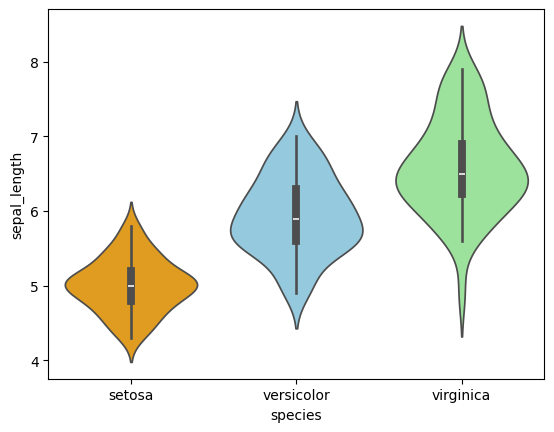

In [49]:
sns.violinplot(
    x="species",
    y="sepal_length",
    data=data,
    hue="species",
    palette=["orange", "skyblue", "lightgreen"],
    legend=False,
)

---

## 8. `countplot` — bars of "how many rows"

```python
sns.countplot(x='species', hue="species", data=data)
```

`countplot` is the only categorical plot with **no `y`**. You give it one column and it
counts rows per value. It is `df['species'].value_counts()` drawn as bars.

```text
   countplot(x="species")           value_counts()
   -------------------------        --------------
   setosa      ##########   50      setosa        50
   versicolor  ##########   50      versicolor    50
   virginica   ##########   50      virginica     50
```

Three bars of exactly equal height, because `iris` is perfectly balanced at 50 rows per
species. If they were *not* equal, that would be your first sign of class imbalance —
which changes how you split data and which metrics you trust later in the ML phases.

Here `hue="species"` duplicates `x` and exists only to colour the bars. See section 17
for the side effect that has.

**Takeaway:** `countplot` counts **rows**; `barplot` averages a **value**. Choosing the
wrong one silently answers a different question.

<Axes: xlabel='species', ylabel='count'>

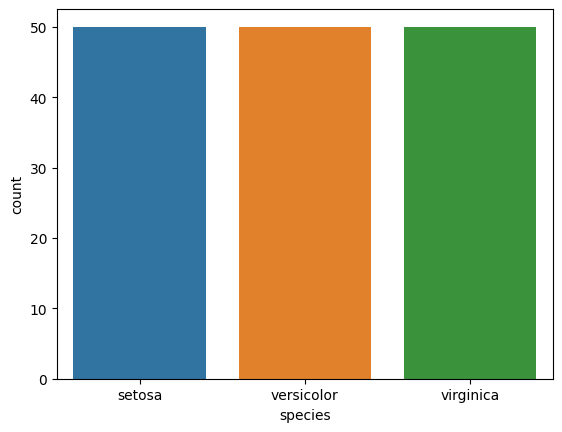

In [51]:
sns.countplot(x ='species',hue="species", data = data)

---

## 9. `barplot` — and the statistics hiding inside it

Now the `titanic` dataset: 891 rows × 15 columns.

| Cell | Call | The one new thing |
|---|---|---|
| A | `titanic = sns.load_dataset("titanic")` | Load. `print` shows 891 rows and columns like `survived`, `pclass`, `sex`, `age`, `fare`, `class`. |
| B | `sns.barplot(x="class", y="fare", data=titanic)` | One bar per class, height = **mean fare**, with a vertical error bar. |
| C | `sns.barplot(..., hue="sex")` | Each class splits into two side-by-side bars, male and female. |

### A bar is not a total — it is a mean

This is the most misread chart in the library. Verified defaults from the 0.13.2
signature:

| Parameter | Default | Meaning |
|---|---|---|
| `estimator` | `"mean"` | bar height is the **average**, not the sum |
| `errorbar` | `("ci", 95)` | the black line is a **95% confidence interval** |
| `n_boot` | `1000` | that interval is bootstrapped from 1000 resamples |
| `width` | `0.8` | bar width as a fraction of the category slot |
| `dodge` | `"auto"` | whether `hue` groups sit side by side |

Verified against pandas on the `tips` data — the bars really are the mean:

```text
seaborn bar heights : 17.683  17.152  20.441  21.410
pandas groupby mean : 17.683  17.152  20.441  21.410   <- identical
```

For titanic, mean fare by class is First **84.15**, Second **20.66**, Third **13.68**.
First-class passengers paid roughly six times Third. If you wanted *total* revenue per
class instead, you must say so:

```python
sns.barplot(x="class", y="fare", data=titanic, estimator="sum", errorbar=None)
```

### Reading the error bar

A long error bar means the mean is unstable — few rows, or values spread widely. A short
one means it is well supported. First class shows a visibly longer bar than Third:
first-class fares varied enormously, third-class fares were all similar and cheap. The
error bar is not decoration; it tells you how much to trust the bar next to it.

Set `errorbar=None` to remove it, but only when you have genuinely decided the reader
does not need it.

### Cell C — `hue` used correctly

`hue="sex"` is a **different** column from `x="class"`, so male and female are real
subgroups inside each class. Side-by-side bars are exactly right here, and the legend is
worth keeping. Contrast this with section 17, where `hue` repeats `x`.

### Common mistakes

1. Reading bar height as a total. It is a mean.
2. Deleting the error bars to make a chart look tidy, and losing the uncertainty signal.
3. Using `barplot` when you wanted `countplot` (row counts) — different question entirely.

**Takeaway:** `barplot` runs a `GROUP BY` and computes a mean with a bootstrapped
confidence interval. Know that before you show one to anybody.

In [26]:
titanic = sns.load_dataset("titanic")
print(titanic)

     survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0           0       3    male  22.0      1      0   7.2500        S   Third   
1           1       1  female  38.0      1      0  71.2833        C   First   
2           1       3  female  26.0      0      0   7.9250        S   Third   
3           1       1  female  35.0      1      0  53.1000        S   First   
4           0       3    male  35.0      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
886         0       2    male  27.0      0      0  13.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   
888         0       3  female   NaN      1      2  23.4500        S   Third   
889         1       1    male  26.0      0      0  30.0000        C   First   
890         0       3    male  32.0      0      0   7.7500        Q   Third   

       who  adult_male deck  embark_town alive  alo

<Axes: xlabel='class', ylabel='fare'>

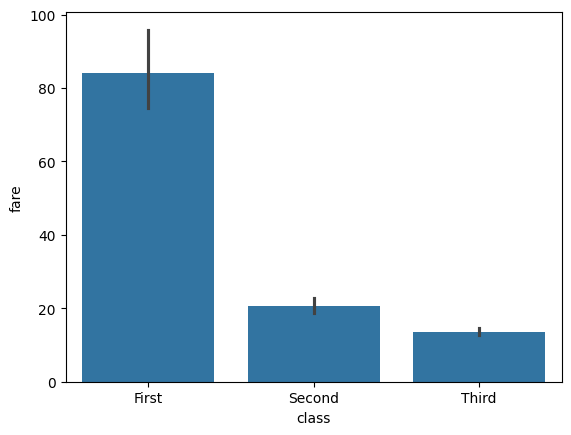

In [27]:
sns.barplot(x="class", y="fare", data=titanic)

<Axes: xlabel='class', ylabel='fare'>

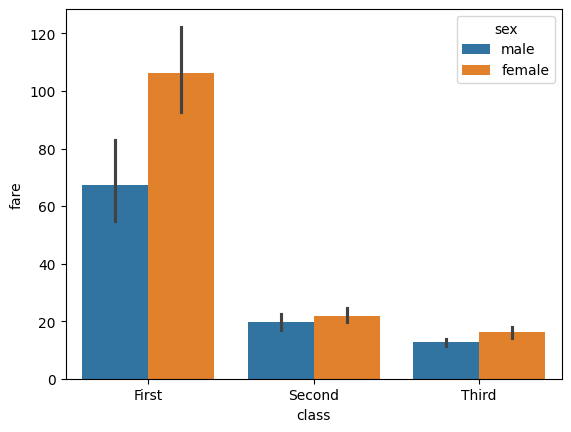

In [28]:
sns.barplot(x="class", y="fare", data=titanic,hue="sex")

---

## 10. `boxplot` — the five-number summary

The `tips` dataset: 244 rows × 7 columns (`total_bill`, `tip`, `sex`, `smoker`, `day`,
`time`, `size`). `day` is a **categorical** column with a fixed order — `Thur, Fri, Sat,
Sun` — which is why seaborn puts the days in calendar order without being asked.

```python
sns.boxplot(x="day", y="total_bill", data=tips, hue="time")
```

Anatomy of one box — verified default `whis=1.5`:

```text
        o    <- outlier: beyond the whisker
        o
        |
      __|__  <- whisker top: last point within 1.5 x IQR
     |     |
     |-----| <- Q3 (75th percentile)
     |     |
     |=====| <- MEDIAN (50th)          IQR = Q3 - Q1 = the box height
     |     |
     |-----| <- Q1 (25th percentile)
     |_____|
        |
        |    <- whisker bottom
```

The whiskers are **not** the min and max. They stop at the furthest point still within
1.5 × IQR of the box; everything past that is drawn as an individual outlier dot. That
rule is why outliers appear as separate points at all.

`hue="time"` splits each day into Lunch and Dinner boxes side by side. This is `hue` used
properly again — `time` is a different column from `day`, so the comparison is real. Note
what it reveals: Thursday has both, but the weekend is dinner-only, so some boxes are
missing. **A missing box is information**, not a bug.

### Box vs violin — pick by question

| Question | Plot |
|---|---|
| Where is the middle, and are there outliers? | `boxplot` |
| What *shape* is the distribution? | `violinplot` |
| Where is every individual row? | `stripplot` / `swarmplot` |

**Takeaway:** a box plot is five numbers — Q1, median, Q3, and two 1.5×IQR whiskers.
It is compact and honest about the middle, and blind to shape.

In [39]:
tips = sns.load_dataset("tips")
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


<Axes: xlabel='day', ylabel='total_bill'>

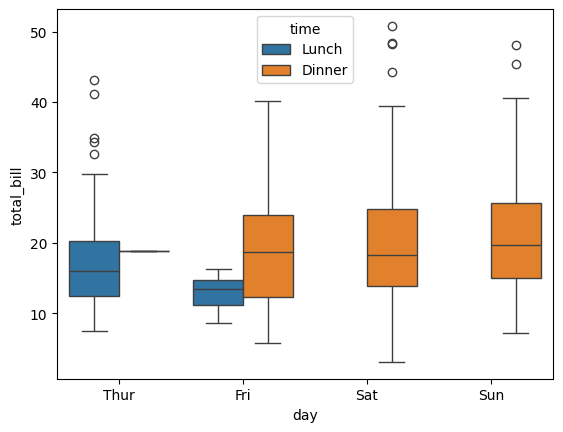

In [43]:
sns.boxplot(x="day", y="total_bill", data=tips,hue="time")

---

## 11. `countplot` variants — orientation and real grouping

Three cells, three lessons.

| Cell | Call | The one new thing |
|---|---|---|
| A | `sns.countplot(x='sex', hue="sex", data=tips)` | Vertical bars. `hue` repeats `x` — colour only. |
| B | `sns.countplot(y='sex', data=tips, hue="sex")` | **`y` instead of `x`** flips the chart to horizontal. |
| C | `sns.countplot(x='sex', data=tips, hue="smoker")` | `hue` is a **different** column — each sex splits into smoker / non-smoker. |

### Horizontal is not just a style choice

Swapping `x=` for `y=` is the whole change in cell B. Use horizontal bars when category
names are long or numerous — the labels stay readable instead of being rotated or
truncated. This applies to `barplot`, `boxplot`, `stripplot` and `swarmplot` too: **which
axis you name decides the orientation.**

### Cell C is the one that answers a question

Cells A and B tell you how many male and female rows exist. Cell C tells you something
you could not otherwise see: the smoker/non-smoker split *within* each sex. That is the
difference between a chart that describes the data and a chart that compares groups.

```text
A / B:  hue == x        ->  colour only, no new information
C:      hue != x        ->  a real second dimension
```

**Takeaway:** `hue` is only worth using when it carries information `x` does not already
carry.

<Axes: xlabel='sex', ylabel='count'>

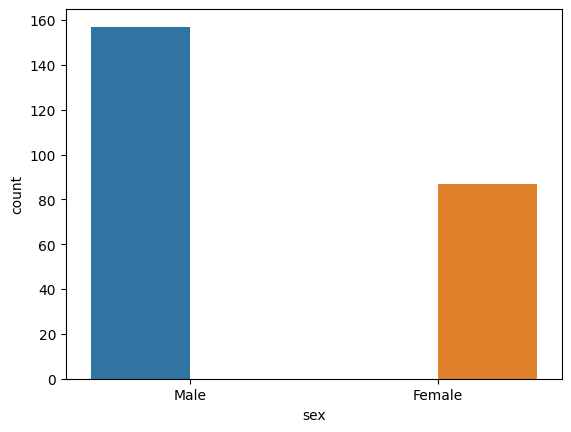

In [53]:
sns.countplot(x ='sex', hue="sex", data = tips)

<Axes: xlabel='count', ylabel='sex'>

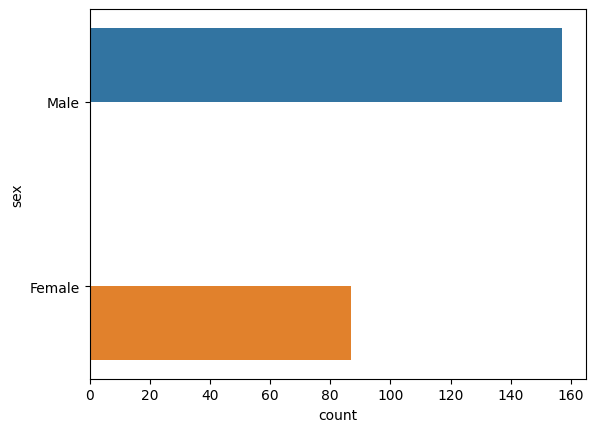

In [55]:
sns.countplot(y ='sex', data = tips,hue="sex")

<Axes: xlabel='sex', ylabel='count'>

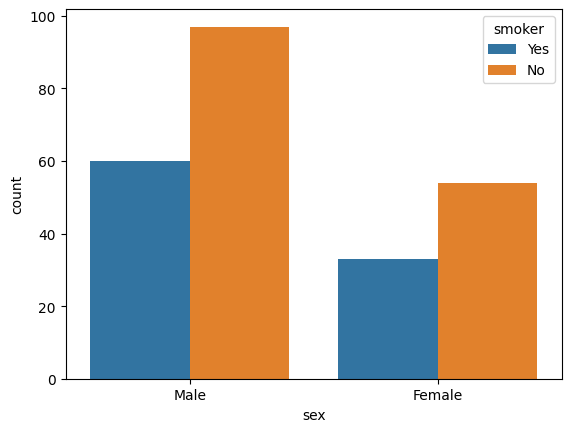

In [56]:
sns.countplot(x ='sex', data = tips,hue = "smoker")

---

## 12. `FacetGrid` — small multiples

```python
abc = sns.FacetGrid(tips, row='smoker', col='time')
abc.map(plt.hist, 'tip', color='gold')
```

Instead of squeezing every group into one chart, **split the data into a grid of small
charts** and let the reader compare panels. Verified: `row='smoker', col='time'` produces
a **2 × 2** grid; `col='time'` alone produces **1 × 2**.

```text
                col = time
              Lunch     Dinner
            +---------+---------+
   row  Yes | subset  | subset  |    each panel = the rows matching
 smoker     |         |         |    that row/column combination
            +---------+---------+
        No  | subset  | subset  |    all panels share the same axes
            |         |         |    so they are directly comparable
            +---------+---------+
```

### The two-step pattern

```text
1. FacetGrid(data, row=..., col=...)   -> build the empty grid, split the data
2. grid.map(function, 'column', ...)   -> run that function once per panel
```

`map` takes a **plotting function object**, not a string: `plt.hist`, `plt.scatter` —
note there are no parentheses. Seaborn calls it for you, once per panel, passing that
panel's subset. Extra keywords like `color='gold'` are forwarded to every call.

| Cell | Call | Result |
|---|---|---|
| A | `.map(plt.hist, 'tip', color='gold')` | one histogram of `tip` per panel — **one** column name because a histogram needs one variable |
| B | `.map(plt.scatter, 'total_bill', 'tip', color='gold')` | one scatter per panel — **two** column names, in `x, y` order |

The number of column names you pass must match what the plotting function expects. That
is the only real rule here.

### Why shared axes matter

Every panel uses the same x and y limits. That is what makes the comparison honest — a
taller bar in one panel really is taller. If each panel scaled itself independently, the
grid would be actively misleading.

> 💡 **Engineering Extension** — *Recommended Extension - Not part of instructor curriculum.*
>
> `FacetGrid` is the general engine underneath the figure-level functions. `pairplot` is a
> specialised grid (every numeric pair); `FacetGrid` is the one you configure yourself.
> In modern seaborn you would usually reach for `sns.displot(...)` or `sns.relplot(...)`,
> which wrap `FacetGrid` and take `col=` / `row=` directly — less code for the same grid.
> `FacetGrid` + `.map` is worth learning because it explains what those wrappers do.

**Takeaway:** when one chart gets crowded, do not add another colour — split it into a
grid. Small multiples with shared axes beat one overloaded chart.

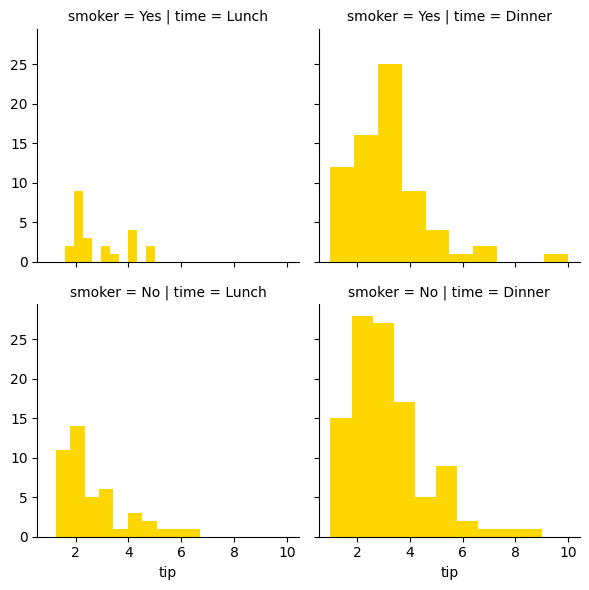

In [57]:
import matplotlib.pyplot as plt
abc = sns.FacetGrid(tips, row ='smoker', col ='time')
abc.map(plt.hist, 'tip',color ='gold')

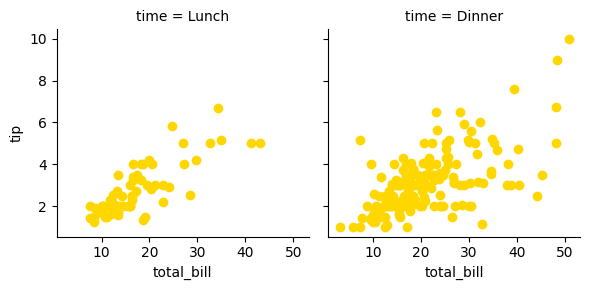

In [58]:
abc = sns.FacetGrid(tips, col ='time')
abc.map(plt.scatter,'total_bill', 'tip',color ='gold')

---

## 13. `stripplot` — every single row as a dot

The setup cell re-imports `matplotlib.pyplot as plt` and reloads `tips`. Harmless
repetition; it makes this part of the notebook runnable on its own.

Bars and boxes **summarise**. A strip plot shows you **every observation**.

| Cell | Call | The one new thing |
|---|---|---|
| A | `sns.stripplot(x="day", y="total_bill", data=tips, hue="day", palette=[4 colours], legend=False)` | Baseline, one colour per day (same `hue` + `palette` rule as section 7 — 4 days need 4 colours). |
| B | `sns.stripplot(..., color="red")` | `color=` — **one** colour for everything. The contrast with A is the lesson. |
| C | `sns.stripplot(..., hue="sex")` | `hue` on a **different** column: two colours inside each day. |

### Jitter — why the dots are scattered sideways

Verified default: `jitter=True`.

```text
jitter=False                    jitter=True (default)
    |                                 |
    #    <- dots stack exactly       . : .
    #       on the tick and hide      :.: .
    #       each other               . :.:
    |                                 |
  measured x spread: 0.0000       measured x spread: 0.1898
```

Every dot in a category has the *same* x value, so without jitter they would all land on
one vertical line and overlap. Seaborn nudges them sideways at random. **The horizontal
position carries no meaning** — it exists purely so you can see density. Only the vertical
position is data.

Turn it off with `jitter=False` when you need exact alignment, and accept the overlap.

### `color` vs `hue` vs `palette` — the summary table

| You want | Argument |
|---|---|
| one colour for the whole plot | `color="red"` |
| split into groups | `hue="<column>"` |
| choose the colours for those groups | `palette=[...]` or `palette="Set2"` |

Cells A and B put this side by side. Cell C shows the version that adds information
rather than decoration.

**Takeaway:** strip plots show the raw rows a box plot hides. Jitter is cosmetic spread,
not data.

In [59]:
import matplotlib.pyplot as plt
tips = sns.load_dataset("tips")

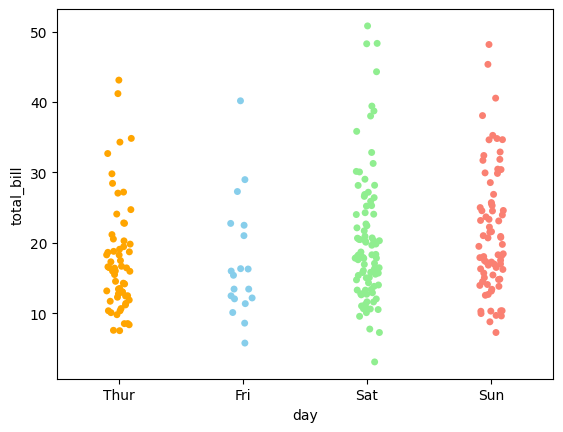

In [61]:
sns.stripplot(
    x="day",
    y="total_bill",
    data=tips,
    hue="day",
    palette=["orange", "skyblue", "lightgreen", "salmon"],
    legend=False,
)
plt.show()

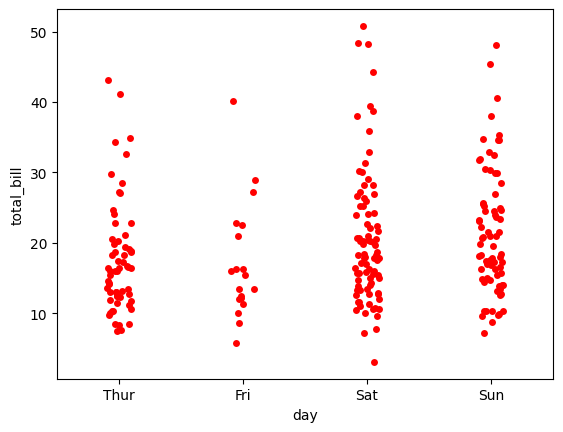

In [62]:
sns.stripplot(
 x="day",
 y="total_bill",
 data=tips,
 color="red"
)
plt.show()

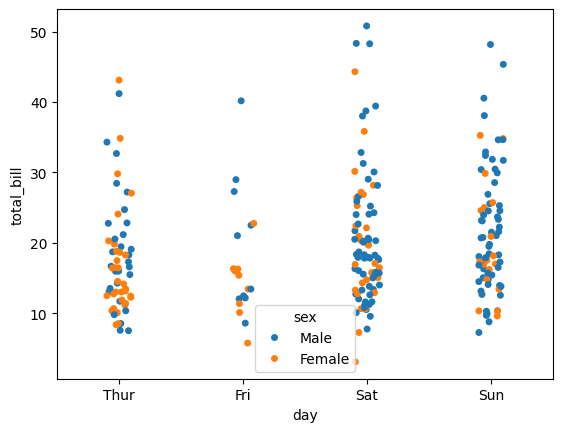

In [63]:
sns.stripplot(
 x="day",
 y="total_bill",
 hue="sex",
 data=tips
)
plt.show()

---

## 14. `swarmplot` — jitter done deliberately

A swarm plot answers the same question as a strip plot but arranges the dots **so that
none of them overlap**.

```text
stripplot (random jitter)        swarmplot (computed positions)
      . : .                              . . .
     :.: .                              . . . .
    . :.:                                . . .
   random, may still collide       packed, never collides
                                   -> the width IS the density
```

Because the algorithm places each point, the **width of the swarm at any height is a real
measurement of how many rows sit at that value**. In a strip plot, width is noise. That is
the entire difference.

| Cell | Call | The one new thing |
|---|---|---|
| A | `sns.swarmplot(x="day", y="total_bill", data=tips, hue="day")` | Baseline swarm. |
| B | `sns.swarmplot(..., size=8)` | `size=` sets **marker size** — the point-plot equivalent of `width=` on a bar. |
| C | `sns.swarmplot(x="total_bill", y="day", ...)` | `x` and `y` **swapped** → horizontal swarm, same data. |

Verified: `size=8` produced **no overflow warning** on these 244 rows — the points still
fit. On a larger dataset seaborn warns that points cannot be placed and some will
overlap, which is the signal that the swarm has outgrown its space.

### The scaling limit — and the honest fix

Swarm plots do not scale. With thousands of rows the algorithm runs out of horizontal
room, warns, and the chart stops being accurate.

```text
under ~1000 rows   ->  swarmplot
thousands of rows  ->  stripplot with alpha, or violinplot, or boxplot
```

### The size knob, per plot family

| Plot | Argument | Meaning |
|---|---|---|
| `barplot` / `boxplot` / `violinplot` | `width=` | fraction of the category slot |
| `stripplot` / `swarmplot` | `size=` | marker diameter |

**Takeaway:** swarm = strip with the overlap solved. Its width means something. Use it on
small data, and fall back to strip or violin when it warns.

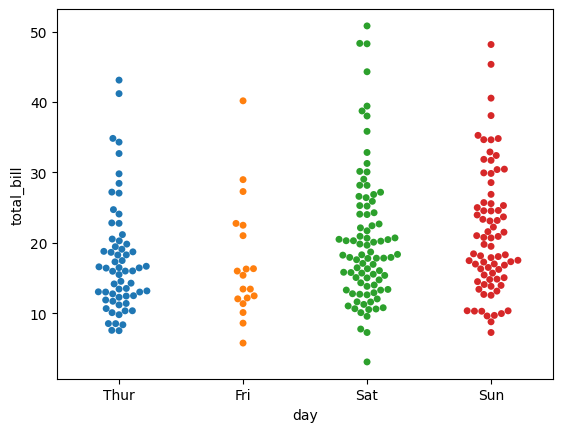

In [65]:
sns.swarmplot(
 x="day",
 y="total_bill",
 data=tips,
 hue= "day"
)
plt.show()

/Users/kaliprasad/Documents/MACHINE_LEARNING/pizza_env/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 5.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


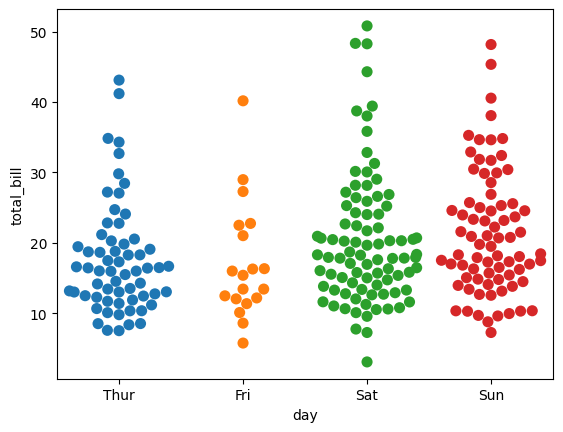

In [67]:
sns.swarmplot(
 x="day",
 y="total_bill",
 data=tips,
 size=8,
 hue="day"
)
plt.show()

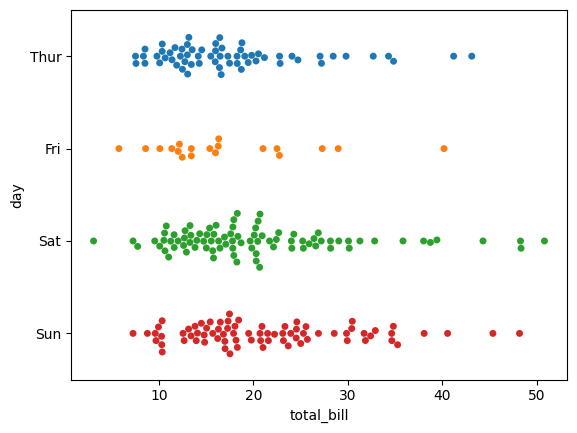

In [69]:
sns.swarmplot(
 x="total_bill",
 y="day",
 data=tips,
 hue="day"
)
plt.show()

---

## 15. `regplot` — scatter plus a fitted line

| Cell | Call | The one new thing |
|---|---|---|
| A | `sns.regplot(x="total_bill", y="tip", data=tips)` | Dots **plus** a fitted regression line **plus** a shaded confidence band. |
| B | `sns.regplot(..., scatter=False)` | `scatter=False` removes the dots and keeps line and band. |

Verified defaults from the signature: `order=1` (straight line), `ci=95`, `n_boot=1000`.
And verified from the drawn objects:

```text
default        -> 2 collections (the dots + the CI band) + 1 line
scatter=False  -> 1 collection  (the CI band only)      + 1 line
```

### What the three parts mean

```text
   tip
    ^          .    .
    |      .  .  ,-'''-.        <- shaded band = 95% CI of the FITTED LINE
    |    . ,.-'''
    |   ,-'  .   .              <- line = ordinary least squares fit, order=1
    | ,' .  .
    +-------------------> total_bill
        dots = the raw rows
```

The band is the uncertainty of **the line**, not the spread of the data. It is narrow in
the middle where there are many rows, and flares at the edges where there are few. That
flare is the chart telling you not to extrapolate.

### Useful variations

```python
sns.regplot(..., order=2)       # fit a curve instead of a line
sns.regplot(..., ci=None)       # drop the band
sns.regplot(..., lowess=True)   # local smoothing, no global model
sns.lmplot(x=..., y=..., hue="smoker", data=tips)   # one line per group
```

`regplot` cannot take `hue`. When you want a separate line per group, use `lmplot`, which
is the figure-level version built on `FacetGrid`.

> 💡 **Engineering Extension** — *Recommended Extension - Not part of instructor curriculum.*
>
> This is a real model fit, but it is an **exploration** tool. It gives you no
> coefficients, no R², no residuals, and no train/test split. When the fit matters, move
> to `scikit-learn` or `statsmodels`. Fitting on the full dataset like this is exactly the
> leakage habit you must avoid once modelling starts — there, you split first and fit only
> on the training portion.

**Takeaway:** `regplot` answers "is there a trend, roughly?" in one line. It is a
conversation starter, not a model.

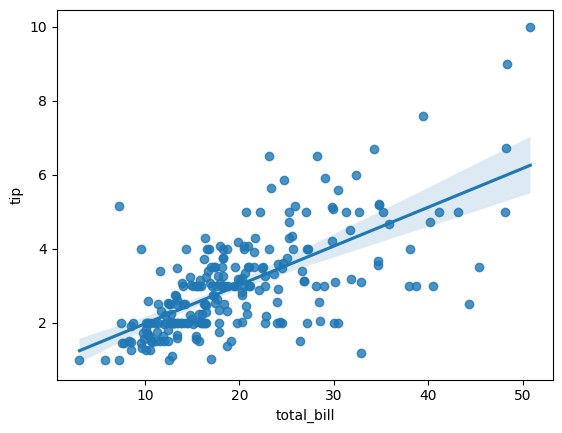

In [72]:
sns.regplot(
 x="total_bill",
 y="tip",
 data=tips,
)
plt.show()

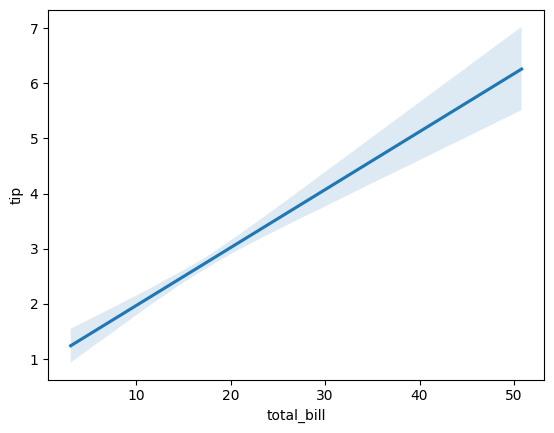

In [73]:
sns.regplot(
 x="total_bill",
 y="tip",
 data=tips,
 scatter=False
)
plt.show()

---

## 16. Themes — `set_theme(style=...)`

Three cells plot the **identical** four-point line. Only the theme changes, which is what
makes the comparison clean.

Verified style settings:

| Style | Axes background | Grid | Tick marks |
|---|---|---|---|
| `darkgrid` | `#EAEAF2` (grey) | on | off |
| `whitegrid` | white | on | off |
| `ticks` | white | off | **on** |

```text
darkgrid            whitegrid           ticks
+----------+        +----------+        +----------+
|##|##|##|#|        |  |  |  | |        |          |
|--+--+--+-|        |--+--+--+-|        |          |
|##|##|##|#|        |  |  |  | |        |          |
+----------+        +----------+        +-|--|--|--+
grey + grid         white + grid        clean + ticks
```

### These calls are global and permanent

`set_theme` mutates matplotlib's `rcParams` for the **rest of the session**. It is not an
argument to one plot:

```text
sns.set_theme(style="whitegrid")
   |
   +--> every chart after this line, in every cell, until you change it again
```

That is why the notebook's earlier charts look different from the later ones — cell order
has a lasting effect. Restore the default with `sns.set_theme()`.

The other two styles are `white` and `dark` (same as the grid versions, without the grid).

> 💡 **Engineering Extension** — *Recommended Extension - Not part of instructor curriculum.*
>
> Global mutable configuration, exactly like calling a static setter at startup. Fine in a
> notebook, where you control the order. Dangerous in a shared library, where you would be
> changing rendering for every caller. The scoped alternative is a context manager:
>
> ```python
> with sns.axes_style("whitegrid"):
>     sns.lineplot(x=[1,2,3,4], y=[10,20,15,25])   # only this plot is affected
> ```

**Which to use:** `whitegrid` for reports and slides, `darkgrid` for screen work,
`ticks` for publication-style figures.

**Takeaway:** `set_theme` is a session-wide switch, not a per-plot argument. Set it once
near the top, or scope it with `axes_style`.

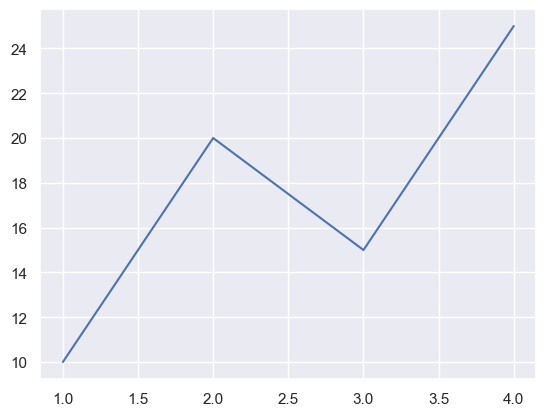

In [74]:
sns.set_theme(style="darkgrid")
sns.lineplot(
 x=[1,2,3,4],
 y=[10,20,15,25]
)
plt.show()

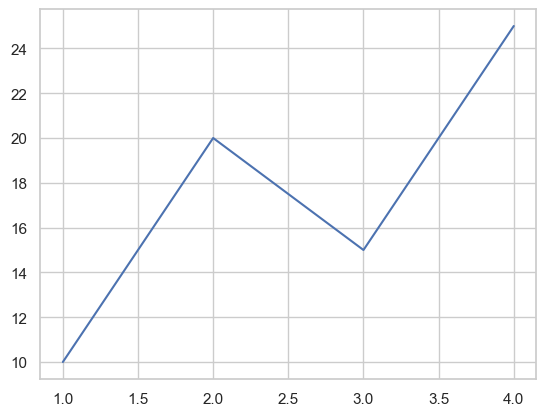

In [75]:
sns.set_theme(style="whitegrid")
sns.lineplot(
 x=[1,2,3,4],
 y=[10,20,15,25]
)
plt.show()

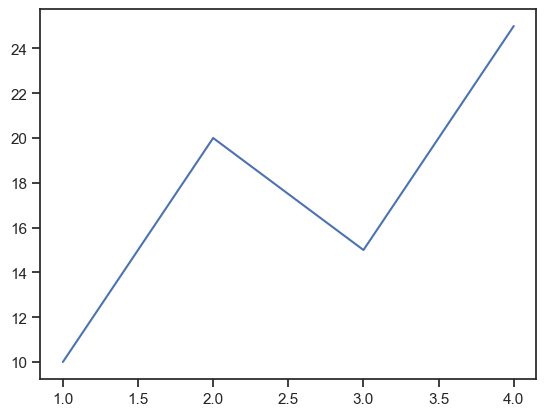

In [76]:
sns.set_theme(style="ticks")
sns.lineplot(
 x=[1,2,3,4],
 y=[10,20,15,25]
)
plt.show()

---

## 17. Palettes, `width`, and the `dodge` trap

`set_palette` is global in exactly the same way `set_theme` is: it changes the default
colour cycle for every chart that follows. Verified — `deep`, `pastel` and `bright` all
contain **10 colours**; they differ in saturation and lightness:

| Palette | First colour (RGB) | Character |
|---|---|---|
| `deep` | `(0.30, 0.45, 0.69)` | muted, the seaborn default |
| `pastel` | `(0.63, 0.79, 0.96)` | light, low contrast |
| `bright` | `(0.01, 0.24, 1.00)` | high saturation |

### The finding that matters most in this section

Verified on this data: **without `hue`, a palette gives you exactly one colour.**

```text
palette=deep    + no hue  ->  1 distinct bar colour
palette=pastel  + no hue  ->  1 distinct bar colour
palette=bright  + no hue  ->  1 distinct bar colour
```

So the last cell, `set_palette("bright")` with no `hue`, produces four bars in a *single*
blue — not four bright colours. Changing the palette changes *which* single colour it is.
This is the same 0.13 rule from section 7, seen from the other side: **a palette needs
something mapped to it before it can spread colours around.**

### The `dodge` trap — measured, not guessed

When `hue` is set, seaborn splits each category slot into one lane per hue level. It does
this **even when `hue` repeats `x`**. Measured bar geometry:

```text
hue="day", width=0.5, dodge="auto"   ->  centre = -0.188   width = 0.125
hue="day", width=0.9, dodge="auto"   ->  centre = -0.338   width = 0.225
hue="day", width=0.9, dodge=False    ->  centre =  0.000   width = 0.900   <- correct
```

The bar was pushed off its tick and shrunk to a quarter width, because 4 lanes were
reserved for 4 "groups" that are really the same thing.

```text
dodge="auto"  (4 lanes reserved)      dodge=False  (one bar, centred)
     Thur slot                             Thur slot
  |-----------|                         |-----------|
   #                                     ###########
   ^ lane 1 of 4, off-centre              ^ centred, full width
```

The same trap is present in the `countplot` cells of sections 8 and 11 — measured centres
of `-0.2` and `1.2` instead of `0` and `1`. Small enough to miss by eye, but the bars are
genuinely not on their ticks.

### The rule

| Situation | Setting |
|---|---|
| `hue` is the **same** column as `x` (colour only) | `dodge=False` |
| `hue` is a **different** column (real comparison) | leave dodging on |

And `width` is a fraction of the 1.0 category slot: `0.8` default, `0.9` wide, `1.0` bars
touching. With `dodge=True` that width is **divided** among the hue lanes; with
`dodge=False` one bar gets all of it.

**Takeaway:** `palette` needs `hue` to do anything, and `hue` that merely repeats `x`
needs `dodge=False` — otherwise seaborn splits a slot that has nothing to split.

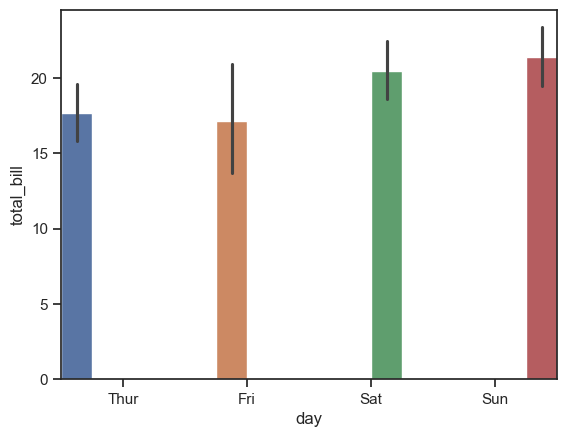

In [83]:
sns.set_palette("deep")
sns.barplot(
    x="day",
    y="total_bill",
    data=tips,
    hue="day",
    width=0.9,
    dodge=False,
)
plt.show()

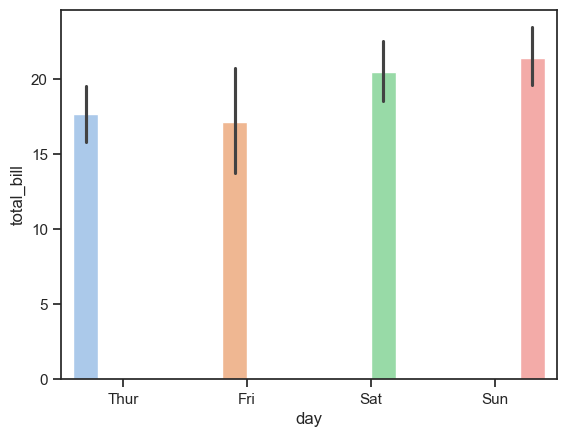

In [81]:
sns.set_palette("pastel")
sns.barplot(
 x="day",
 y="total_bill",
 data=tips,
 hue="day"
)
plt.show()

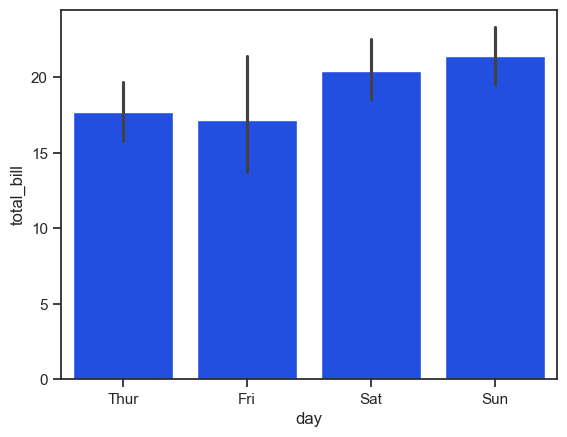

In [82]:
sns.set_palette("bright")
sns.barplot(
 x="day",
 y="total_bill",
 data=tips
)
plt.show()

---

## Closing — what this notebook establishes

### The one pattern behind every cell

```text
sns.<plot>(x=<column>, y=<column>, hue=<column>, data=<DataFrame>)
              |            |          |            |
        which column  which column  how to     long-form
        on the x      on the y      split      rows
```

Learn that shape once and the whole library opens up. The plot name changes; the argument
structure does not.

### Choosing the plot

```text
How many variables?
  |
  +-- ONE numeric        -> histplot / kdeplot
  |
  +-- TWO numeric        -> scatterplot        (relationship)
  |                      -> regplot            (relationship + trend line)
  |                      -> lineplot           (ONLY if x is ordered, e.g. time)
  |
  +-- CATEGORY + numeric -> barplot            (mean per group)
  |                      -> boxplot            (five-number summary)
  |                      -> violinplot         (full shape)
  |                      -> stripplot/swarmplot(every row)
  |
  +-- CATEGORY alone     -> countplot          (row counts)
  |
  +-- MANY numeric       -> pairplot           (all pairs at once)
  |
  +-- too crowded        -> FacetGrid          (split into small multiples)
```

### Common mistakes this notebook demonstrates

1. **`hue` takes a column name, never a colour.** `color=` takes a colour.
2. **`palette` does nothing without `hue`** — verified: one colour, whatever the palette.
3. **`hue` repeating `x` still dodges** — measured off-centre bars. Add `dodge=False`.
4. **`lineplot` aggregates** — 50 setosa rows became 15 points plus a bootstrapped CI band.
5. **A bar is a mean, not a total** — verified equal to `groupby().mean()`.
6. **Box whiskers are 1.5 × IQR, not min and max.**
7. **`set_theme` and `set_palette` are global** and persist for the rest of the session.
8. **`swarmplot` does not scale** past roughly a thousand rows.

### Interview view

- **"Seaborn vs matplotlib?"** Seaborn is a statistical layer on top of matplotlib. It
  takes a DataFrame and column names, does the grouping and aggregation, and returns a
  matplotlib `Axes`. Matplotlib draws exactly what you pass it; seaborn computes first.
- **"What does `hue` do?"** It maps a column to colour — effectively a `GROUP BY` that
  splits the data, re-runs the plot's statistic per group, and builds a legend.
- **"Figure-level vs axes-level?"** Axes-level functions draw into one Axes and return it.
  Figure-level functions (`pairplot`, `lmplot`, `FacetGrid`, `displot`, `relplot`) create
  their own Figure and cannot be placed inside an existing subplot.
- **"Which plot for a distribution across groups?"** `boxplot` for the summary,
  `violinplot` when shape matters, `stripplot`/`swarmplot` to show every row.
- **"What does the shaded band mean?"** In `lineplot` and `barplot` it is a bootstrapped
  95% confidence interval of the estimate. In `regplot` it is the CI of the fitted line.

### Key takeaway

**If you remember only one thing:** seaborn plots *columns*, not numbers — and it runs
statistics on them before drawing. `hue` is a `GROUP BY`, a bar is a mean, a band is a
confidence interval. Know what has been computed before you trust the picture.

---

**Next in M02:** Plotly (interactive charts), then Streamlit in M04 to put these charts
behind a UI.